In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV,
                                     RandomizedSearchCV, learning_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import (GradientBoostingClassifier,
                              AdaBoostClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             roc_curve, precision_recall_curve,
                             ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

In [2]:
path = kagglehub.dataset_download(
    "jessemostipak/hotel-booking-demand")
print("📁 Path:", path)

csv_file = os.path.join(path, "hotel_bookings.csv")
df = pd.read_csv(csv_file)

print(f"\n✅ Dataset Loaded!")
print(f"📐 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

100%|██████████| 1.25M/1.25M [00:00<00:00, 83.1MB/s]

Extracting files...
📁 Path: /root/.cache/kagglehub/datasets/jessemostipak/hotel-booking-demand/versions/1



✅ Dataset Loaded!
📐 Shape: 119390 rows × 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


In [5]:
num_cols = df.select_dtypes(
    include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(
    include=['object']).columns.tolist()

print(f"\n🔢 Numerical ({len(num_cols)}): {num_cols}")
print(f"\n🔤 Categorical ({len(cat_cols)}): {cat_cols}")

print(f"\n🎯 Target: is_canceled")
print(df['is_canceled'].value_counts())
print(f"\nCancellation Rate: "
      f"{df['is_canceled'].mean()*100:.1f}%")


🔢 Numerical (20): ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

🔤 Categorical (12): ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']

🎯 Target: is_canceled
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Cancellation Rate: 37.0%


In [6]:
print("🔍 Missing Values:")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

# Fill missing values
df['children'].fillna(0, inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['agent'].fillna(0, inplace=True)
df['company'].fillna(0, inplace=True)
print("\n✅ Missing values handled:")
print("   → children  : filled with 0")
print("   → country   : filled with 'Unknown'")
print("   → agent     : filled with 0")
print("   → company   : filled with 0")

🔍 Missing Values:
company     112593
agent        16340
country        488
children         4
dtype: int64

✅ Missing values handled:
   → children  : filled with 0
   → country   : filled with 'Unknown'
   → agent     : filled with 0
   → company   : filled with 0


In [7]:
dups = df.duplicated().sum()
print(f"\n🔍 Duplicate rows: {dups}")
if dups > 0:
    df.drop_duplicates(inplace=True)
    print(f"✅ {dups} duplicates removed!")
else:
    print("✅ No duplicates found!")



🔍 Duplicate rows: 31994
✅ 31994 duplicates removed!


In [8]:
drop_cols = ['reservation_status',
             'reservation_status_date',
             'name', 'email', 'phone-number',
             'credit_card']
drop_cols = [c for c in drop_cols
             if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print(f"\n✅ Dropped irrelevant columns: {drop_cols}")


✅ Dropped irrelevant columns: ['reservation_status', 'reservation_status_date']


In [9]:
invalid_adr = (df['adr'] < 0).sum()
df = df[df['adr'] >= 0]
print(f"✅ Removed {invalid_adr} rows with negative adr")

# guests = 0 (no adults, children or babies)
invalid_guests = (
    (df['adults'] == 0) &
    (df['children'] == 0) &
    (df['babies'] == 0)).sum()
df = df[~((df['adults'] == 0) &
           (df['children'] == 0) &
           (df['babies'] == 0))]
print(f"✅ Removed {invalid_guests} rows "
      f"with 0 total guests")

✅ Removed 1 rows with negative adr
✅ Removed 166 rows with 0 total guests


In [10]:
top_countries = df['country'].value_counts(
    ).head(20).index.tolist()
df['country'] = df['country'].apply(
    lambda x: x if x in top_countries else 'Other')
print("✅ Country: top 20 kept, rest → 'Other'")

✅ Country: top 20 kept, rest → 'Other'


In [11]:
obj_cols = df.select_dtypes(include='object').columns
df[obj_cols] = df[obj_cols].apply(
    lambda x: x.str.strip())
print("✅ Whitespace stripped")

✅ Whitespace stripped


In [12]:
num_feats = df.select_dtypes(
    include=[np.number]).columns.tolist()
num_feats = [c for c in num_feats
             if c != 'is_canceled']
outlier_info = {}

for col in num_feats:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    out = df[(df[col] < Q1 - 1.5*IQR) |
             (df[col] > Q3 + 1.5*IQR)].shape[0]
    if out > 0:
        outlier_info[col] = out

print(f"  Columns with outliers: {len(outlier_info)}")

# Cap outliers
for col in outlier_info.keys():
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(
        lower=Q1 - 1.5*IQR,
        upper=Q3 + 1.5*IQR)
print("✅ Outliers capped (Winsorization)")

print(f"\n📐 Cleaned Shape: {df.shape}")

  Columns with outliers: 15
✅ Outliers capped (Winsorization)

📐 Cleaned Shape: (87229, 30)


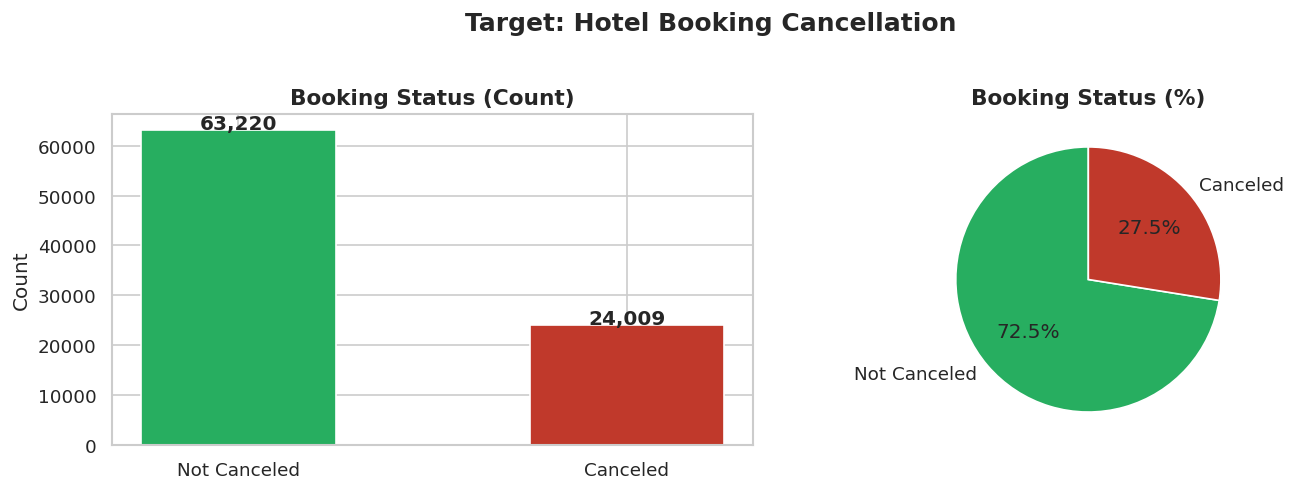

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cancel_counts = df['is_canceled'].value_counts()
labels        = ['Not Canceled', 'Canceled']

axes[0].bar(labels,
            cancel_counts.values,
            color=['#27ae60', '#c0392b'],
            edgecolor='white', width=0.5)
axes[0].set_title('Booking Status (Count)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(cancel_counts.values):
    axes[0].text(i, v + 200, f'{v:,}',
                 ha='center', fontweight='bold')

axes[1].pie(cancel_counts.values,
            labels=labels,
            autopct='%1.1f%%',
            colors=['#27ae60', '#c0392b'],
            startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Booking Status (%)',
                  fontsize=13, fontweight='bold')

plt.suptitle('Target: Hotel Booking Cancellation',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('GB_01_cancellation_dist.png',
            bbox_inches='tight')
plt.show()

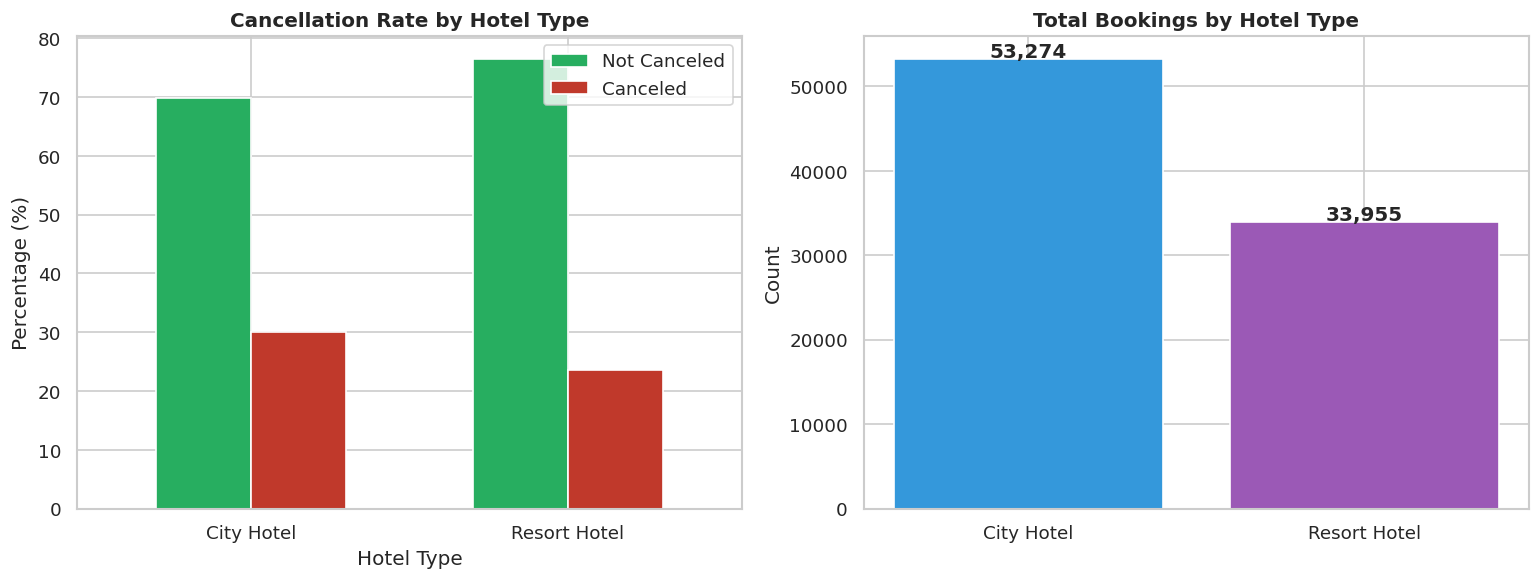

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

hotel_cancel = pd.crosstab(
    df['hotel'], df['is_canceled'],
    normalize='index') * 100
hotel_cancel.columns = ['Not Canceled', 'Canceled']
hotel_cancel.plot(kind='bar', ax=axes[0],
                  color=['#27ae60', '#c0392b'],
                  edgecolor='white', width=0.6)
axes[0].set_title('Cancellation Rate by Hotel Type',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hotel Type')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend()

# Bookings count by hotel type
hotel_counts = df['hotel'].value_counts()
axes[1].bar(hotel_counts.index,
            hotel_counts.values,
            color=['#3498db', '#9b59b6'],
            edgecolor='white')
axes[1].set_title('Total Bookings by Hotel Type',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(hotel_counts.values):
    axes[1].text(i, v + 200, f'{v:,}',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('GB_02_hotel_analysis.png',
            bbox_inches='tight')
plt.show()

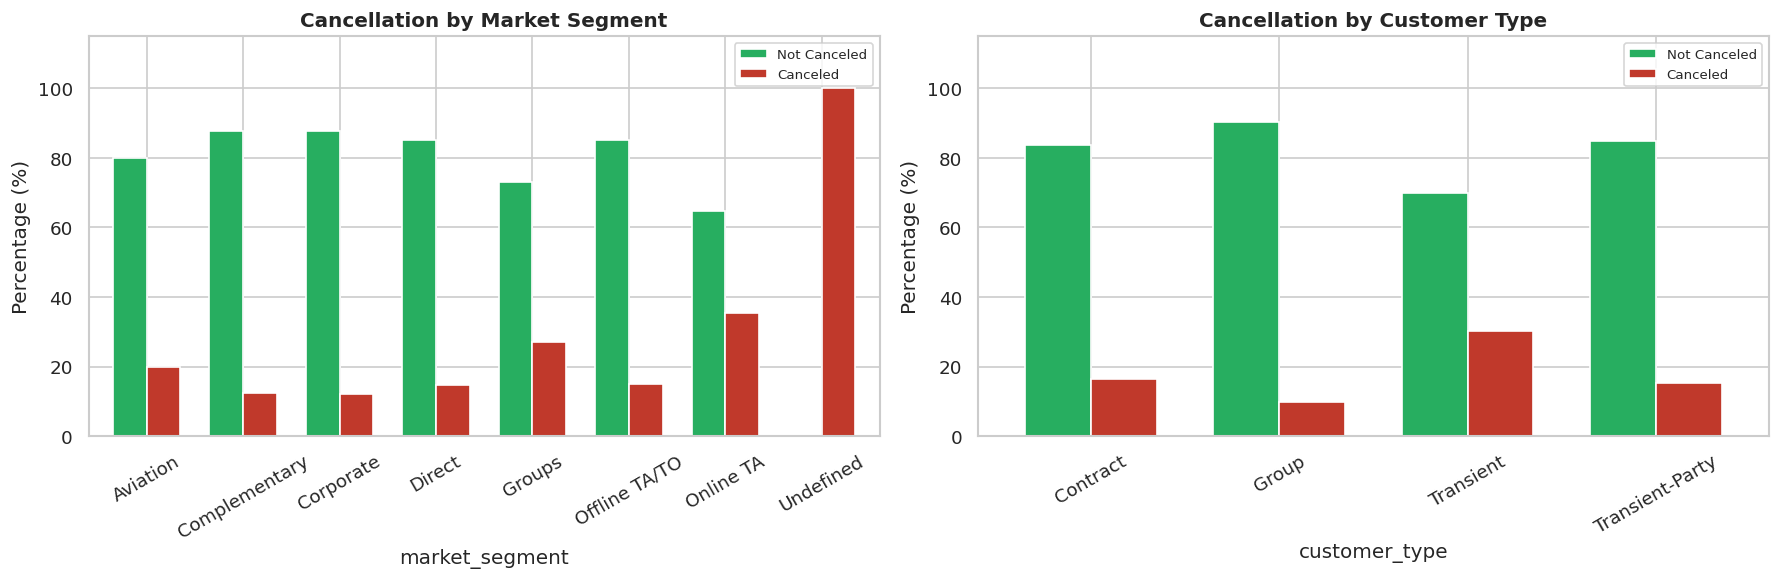

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, col, title in zip(
        axes,
        ['market_segment', 'customer_type'],
        ['Market Segment', 'Customer Type']):
    ct = pd.crosstab(
        df[col], df['is_canceled'],
        normalize='index') * 100
    ct.columns = ['Not Canceled', 'Canceled']
    ct.plot(kind='bar', ax=ax,
            color=['#27ae60', '#c0392b'],
            edgecolor='white', width=0.7)
    ax.set_title(f'Cancellation by {title}',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    ax.set_ylim(0, 115)

plt.tight_layout()
plt.savefig('GB_03_segment_analysis.png',
            bbox_inches='tight')
plt.show()

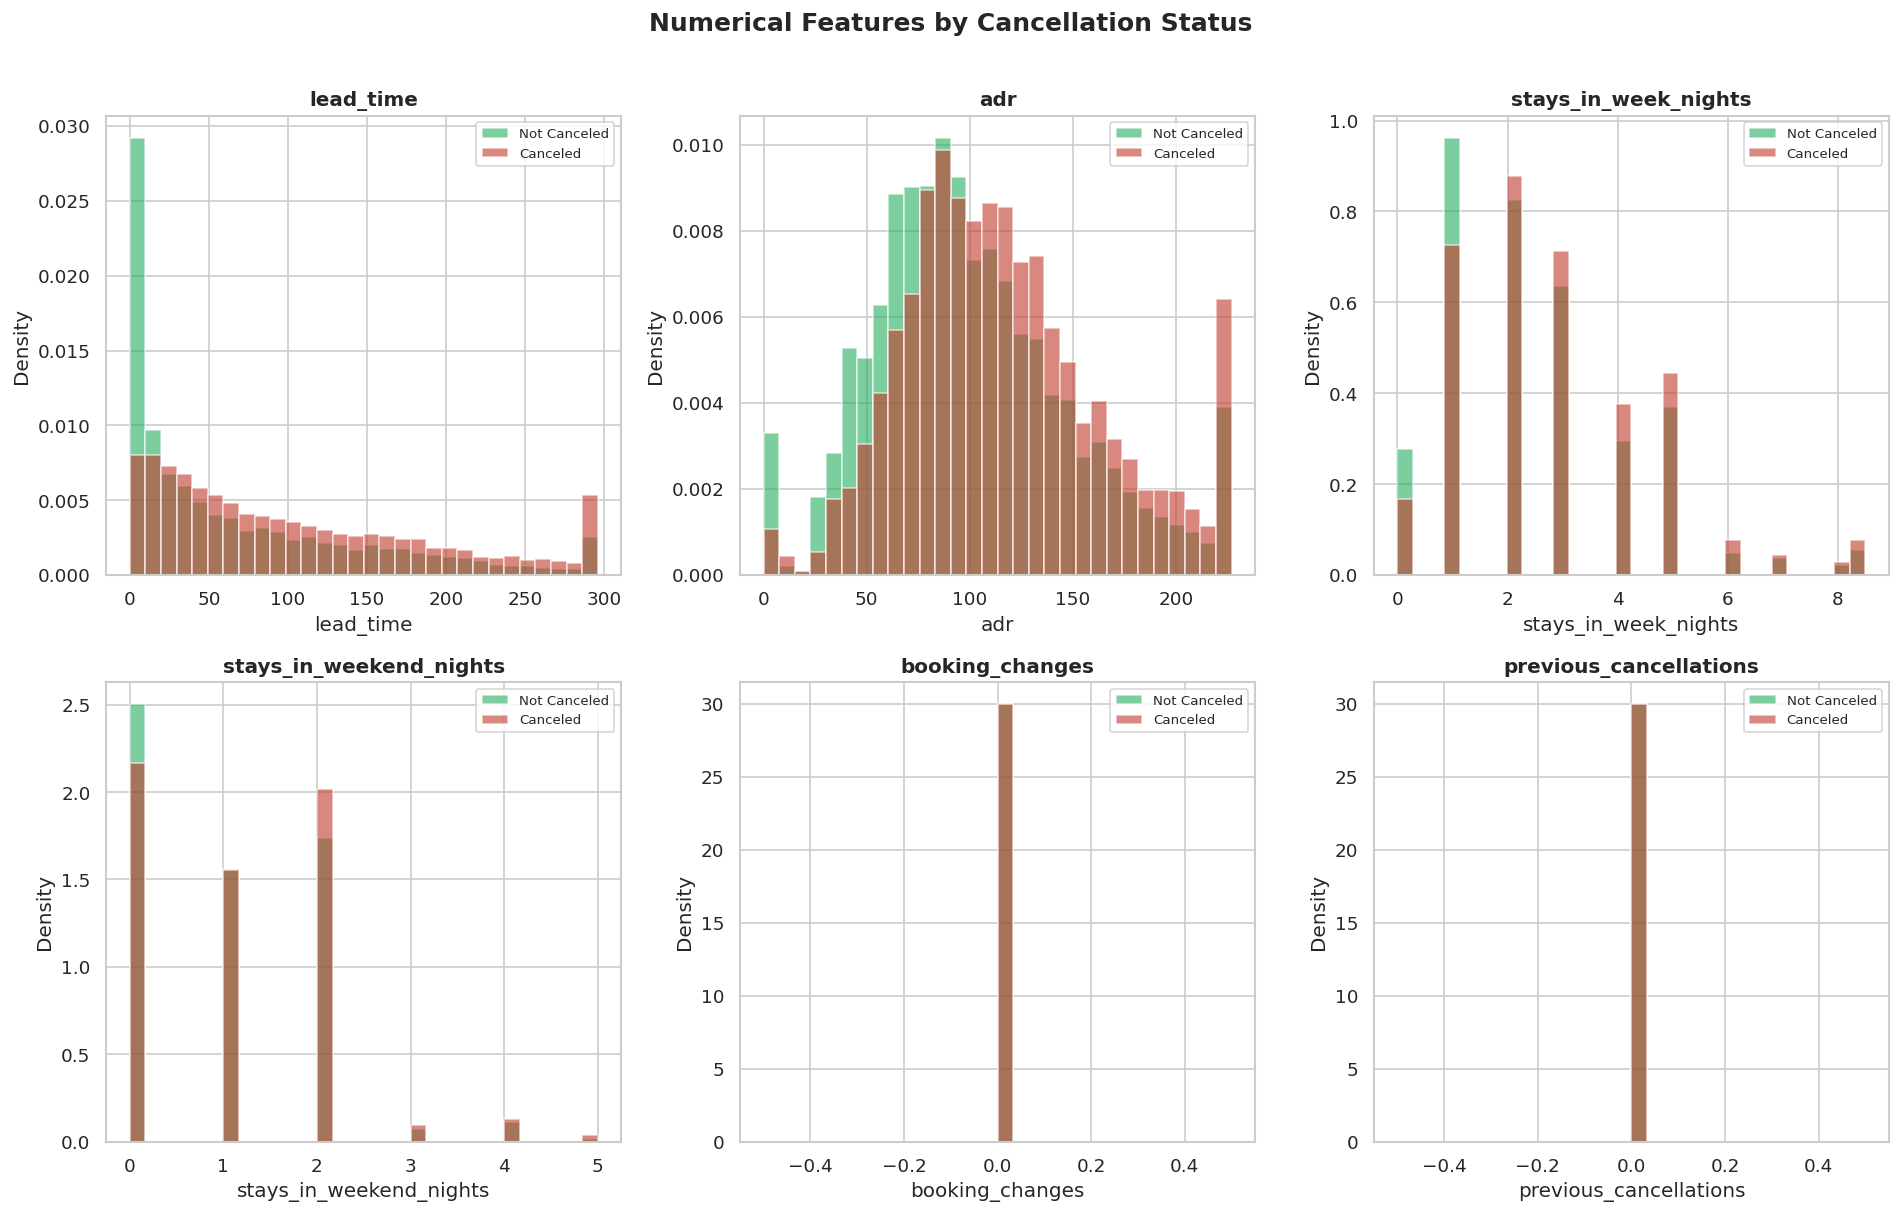

In [16]:
num_plot = ['lead_time', 'adr',
            'stays_in_week_nights',
            'stays_in_weekend_nights',
            'booking_changes',
            'previous_cancellations']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_plot):
    axes[i].hist(
        df[df['is_canceled']==0][col],
        bins=30, alpha=0.6,
        color='#27ae60', label='Not Canceled',
        density=True)
    axes[i].hist(
        df[df['is_canceled']==1][col],
        bins=30, alpha=0.6,
        color='#c0392b', label='Canceled',
        density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Numerical Features by Cancellation Status',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('GB_04_numerical_dist.png',
            bbox_inches='tight')
plt.show()

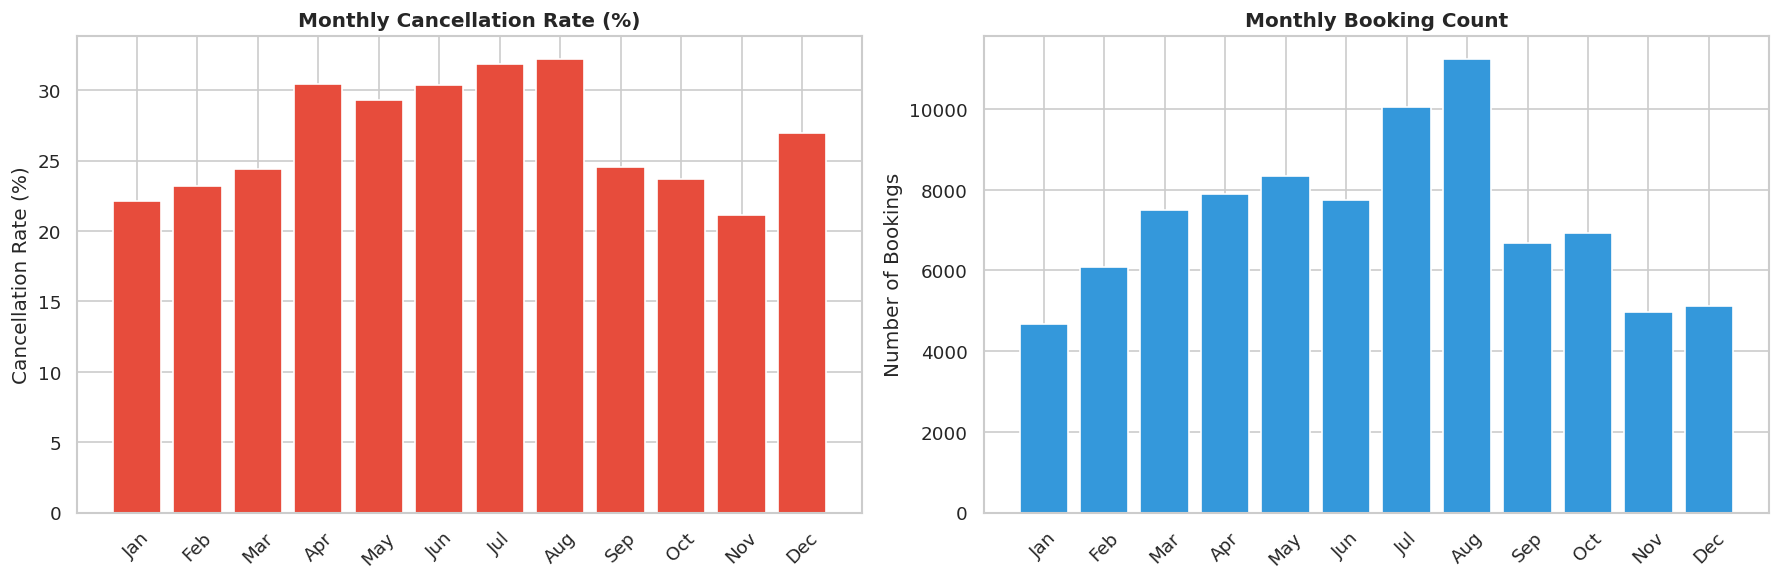

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

month_order = ['January', 'February', 'March',
               'April', 'May', 'June', 'July',
               'August', 'September', 'October',
               'November', 'December']
month_order = [m for m in month_order
               if m in df['arrival_date_month'].unique()]

monthly = df.groupby('arrival_date_month')[
    'is_canceled'].agg(['mean', 'count']).reindex(
    month_order)

axes[0].bar(range(len(monthly)),
            monthly['mean'] * 100,
            color='#e74c3c', edgecolor='white')
axes[0].set_title('Monthly Cancellation Rate (%)',
                  fontsize=12, fontweight='bold')
axes[0].set_xticks(range(len(monthly)))
axes[0].set_xticklabels(
    [m[:3] for m in monthly.index],
    rotation=45)
axes[0].set_ylabel('Cancellation Rate (%)')

axes[1].bar(range(len(monthly)),
            monthly['count'],
            color='#3498db', edgecolor='white')
axes[1].set_title('Monthly Booking Count',
                  fontsize=12, fontweight='bold')
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(
    [m[:3] for m in monthly.index],
    rotation=45)
axes[1].set_ylabel('Number of Bookings')

plt.tight_layout()
plt.savefig('GB_05_monthly_analysis.png',
            bbox_inches='tight')
plt.show()

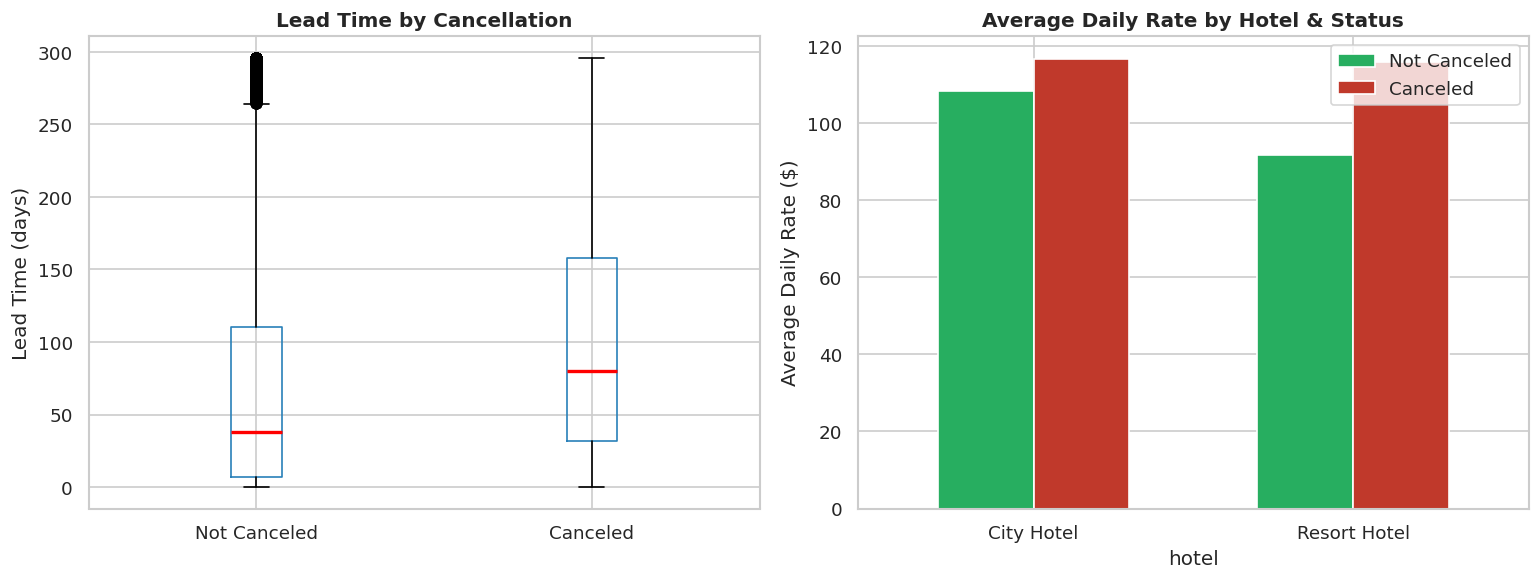

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].boxplot(
    [df[df['is_canceled']==0]['lead_time'],
     df[df['is_canceled']==1]['lead_time']],
    labels=['Not Canceled', 'Canceled'],
    boxprops=dict(color='#2980b9'),
    medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Lead Time by Cancellation',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Lead Time (days)')

# ADR by hotel type and cancellation
adr_data = df.groupby(
    ['hotel', 'is_canceled'])['adr'].mean().unstack()
adr_data.columns = ['Not Canceled', 'Canceled']
adr_data.plot(kind='bar', ax=axes[1],
              color=['#27ae60', '#c0392b'],
              edgecolor='white', width=0.6)
axes[1].set_title('Average Daily Rate by Hotel & Status',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Daily Rate ($)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('GB_06_leadtime_adr.png',
            bbox_inches='tight')
plt.show()

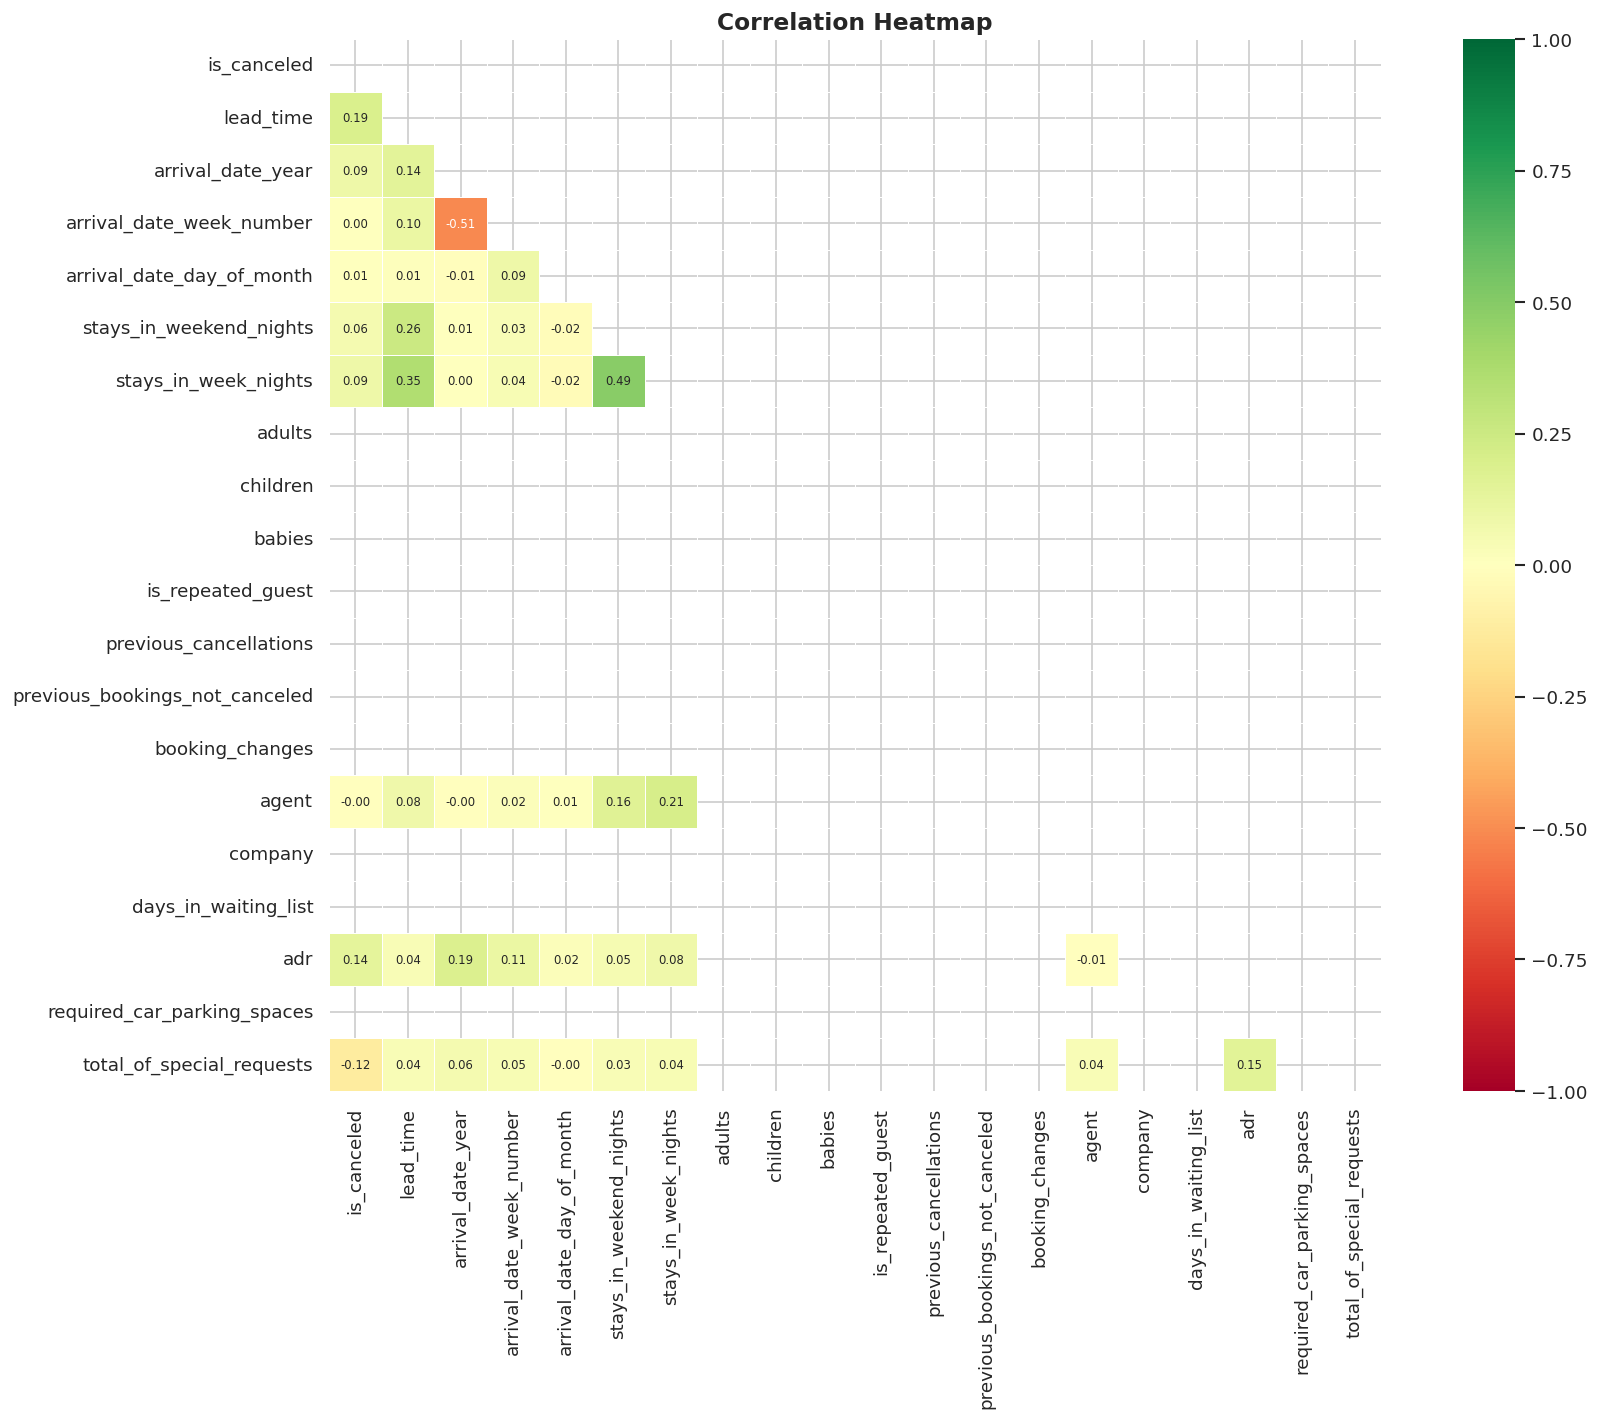

In [19]:
fig, ax = plt.subplots(figsize=(16, 12))

num_df = df.select_dtypes(include=[np.number])
corr   = num_df.corr()
mask   = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask,
            annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.3,
            ax=ax, annot_kws={'fontsize': 7},
            vmin=-1, vmax=1, center=0,
            square=True)
ax.set_title('Correlation Heatmap',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('GB_07_correlation_heatmap.png',
            bbox_inches='tight')
plt.show()

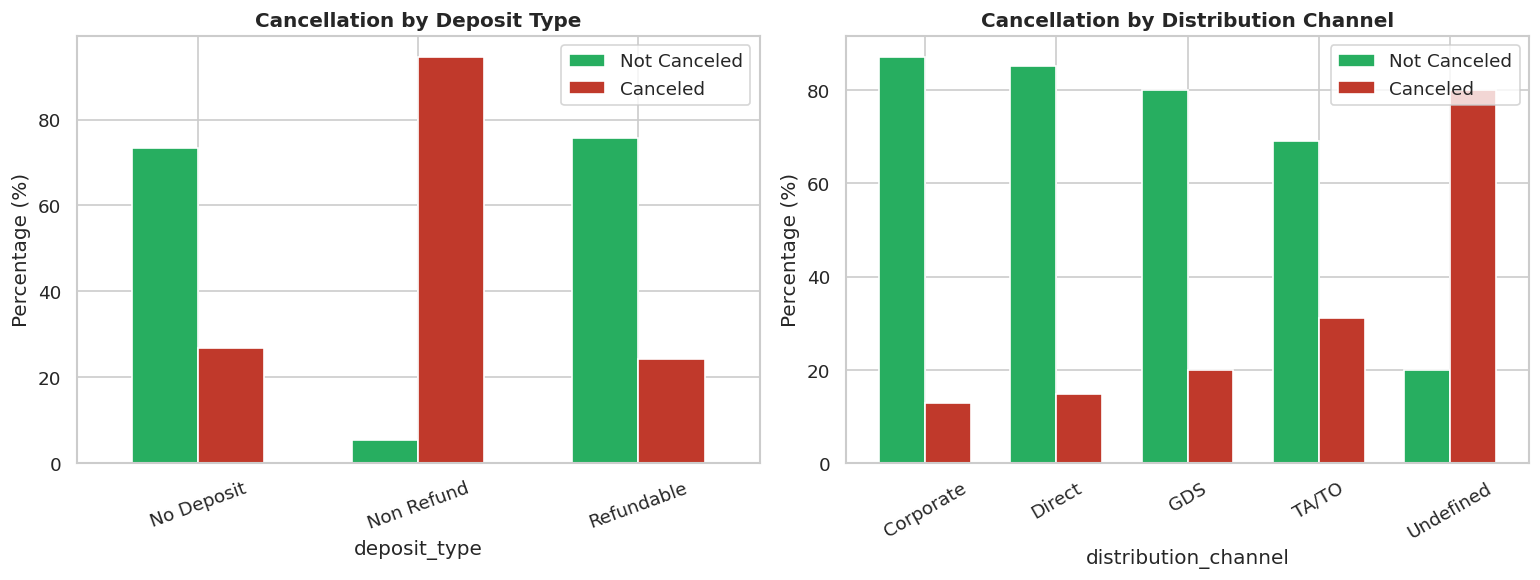

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

deposit_cancel = pd.crosstab(
    df['deposit_type'], df['is_canceled'],
    normalize='index') * 100
deposit_cancel.columns = ['Not Canceled', 'Canceled']
deposit_cancel.plot(kind='bar', ax=axes[0],
                    color=['#27ae60', '#c0392b'],
                    edgecolor='white', width=0.6)
axes[0].set_title('Cancellation by Deposit Type',
                  fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylabel('Percentage (%)')
axes[0].legend()

# Distribution channels
channel_cancel = pd.crosstab(
    df['distribution_channel'],
    df['is_canceled'],
    normalize='index') * 100
channel_cancel.columns = ['Not Canceled', 'Canceled']
channel_cancel.plot(kind='bar', ax=axes[1],
                    color=['#27ae60', '#c0392b'],
                    edgecolor='white', width=0.7)
axes[1].set_title('Cancellation by Distribution Channel',
                  fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylabel('Percentage (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('GB_08_deposit_channel.png',
            bbox_inches='tight')
plt.show()

In [21]:
df_model = df.copy()

# ── 6.1 Target already encoded (0/1)
print("✅ Target 'is_canceled' already 0/1")

# ── 6.2 Month → Ordinal
month_map = {
    'January':1, 'February':2, 'March':3,
    'April':4, 'May':5, 'June':6,
    'July':7, 'August':8, 'September':9,
    'October':10, 'November':11, 'December':12}
df_model['arrival_date_month'] = df_model[
    'arrival_date_month'].map(month_map)
print("✅ Month → Ordinal (1-12)")

# ── 6.3 Binary Encoding
binary_cols = {
    'hotel'            : {'City Hotel':0,
                          'Resort Hotel':1},
    'is_repeated_guest': {0:0, 1:1},
}
for col, mapping in binary_cols.items():
    if col in df_model.columns:
        df_model[col] = df_model[col].map(mapping)
print("✅ Binary columns encoded")

# ── 6.4 One-Hot Encoding
cat_remaining = df_model.select_dtypes(
    include='object').columns.tolist()
print(f"\n🔤 One-Hot encoding: {cat_remaining}")
df_model = pd.get_dummies(
    df_model,
    columns=cat_remaining,
    drop_first=True)
print(f"✅ One-Hot Encoding applied")

# ── 6.5 Handle nulls
df_model.fillna(
    df_model.median(numeric_only=True),
    inplace=True)

print(f"\n📐 Final Shape: {df_model.shape}")
df_model.head(3)

✅ Target 'is_canceled' already 0/1
✅ Month → Ordinal (1-12)
✅ Binary columns encoded

🔤 One-Hot encoding: ['meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
✅ One-Hot Encoding applied

📐 Final Shape: (87229, 80)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,1,0,296,2015,7,27,1,0,0.0,2,...,False,False,False,False,False,False,False,False,True,False
1,1,0,296,2015,7,27,1,0,0.0,2,...,False,False,False,False,False,False,False,False,True,False
2,1,0,7,2015,7,27,1,0,1.0,2,...,False,False,False,False,False,False,False,False,True,False


In [22]:
# Total nights stayed
df_model['total_nights'] = (
    df_model['stays_in_week_nights'] +
    df_model['stays_in_weekend_nights'])
print("✅ 'total_nights' created")

# Total guests
df_model['total_guests'] = (
    df_model['adults'] +
    df_model['children'] +
    df_model['babies'])
print("✅ 'total_guests' created")

# Revenue per booking
df_model['total_revenue'] = (
    df_model['adr'] *
    df_model['total_nights'])
print("✅ 'total_revenue' created")

# Has special requests
df_model['has_special_requests'] = (
    df_model['total_of_special_requests'] > 0
).astype(int)
print("✅ 'has_special_requests' created")

# Booking was changed
df_model['was_changed'] = (
    df_model['booking_changes'] > 0
).astype(int)
print("✅ 'was_changed' created")

# High lead time flag (>90 days)
df_model['high_lead_time'] = (
    df_model['lead_time'] > 90
).astype(int)
print("✅ 'high_lead_time' created")

# Previous cancellation rate
df_model['prev_cancel_rate'] = (
    df_model['previous_cancellations'] /
    (df_model['previous_bookings_not_canceled'] + 1))
print("✅ 'prev_cancel_rate' created")

print(f"\n📐 Final Shape: {df_model.shape}")


✅ 'total_nights' created
✅ 'total_guests' created
✅ 'total_revenue' created
✅ 'has_special_requests' created
✅ 'was_changed' created
✅ 'high_lead_time' created
✅ 'prev_cancel_rate' created

📐 Final Shape: (87229, 87)


In [23]:
X = df_model.drop(columns=['is_canceled'])
y = df_model['is_canceled']

print(f"🎯 Target distribution:")
print(f"   Not Canceled (0): {(y==0).sum():,}")
print(f"   Canceled (1)    : {(y==1).sum():,}")
print(f"   Cancel Rate     : {y.mean()*100:.1f}%")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y)

# GB does NOT require scaling
# but keeping for reference
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n✅ Training set : {X_train.shape}")
print(f"✅ Test set     : {X_test.shape}")
print(f"✅ Features     : {X_train.shape[1]}")
print("\n📌 GB does NOT require scaling!")

🎯 Target distribution:
   Not Canceled (0): 63,220
   Canceled (1)    : 24,009
   Cancel Rate     : 27.5%

✅ Training set : (69783, 86)
✅ Test set     : (17446, 86)
✅ Features     : 86

📌 GB does NOT require scaling!


In [24]:
baseline_models = {
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators = 100,
        random_state = 42),
    'AdaBoost': AdaBoostClassifier(
        n_estimators = 100,
        random_state = 42),
    'AdaBoost+DT': AdaBoostClassifier(
        estimator    = DecisionTreeClassifier(
                           max_depth=3),
        n_estimators = 100,
        random_state = 42),
}

baseline_results = {}

for name, model in baseline_models.items():
    print(f"\n  Training {name}...")
    model.fit(X_train, y_train)
    y_p  = model.predict(X_test)
    y_pp = model.predict_proba(X_test)[:, 1]
    acc  = accuracy_score(y_test, y_p)
    roc  = roc_auc_score(y_test, y_pp)
    baseline_results[name] = {
        'model': model,
        'acc'  : acc,
        'roc'  : roc}
    print(f"    Accuracy : {acc*100:.2f}%")
    print(f"    ROC-AUC  : {roc:.4f}")

best_baseline = max(
    baseline_results,
    key=lambda k: baseline_results[k]['roc'])
print(f"\n🏆 Best Baseline: {best_baseline}")


  Training GradientBoosting...
    Accuracy : 81.57%
    ROC-AUC  : 0.8703

  Training AdaBoost...
    Accuracy : 78.48%
    ROC-AUC  : 0.8277

  Training AdaBoost+DT...
    Accuracy : 81.26%
    ROC-AUC  : 0.8691

🏆 Best Baseline: GradientBoosting


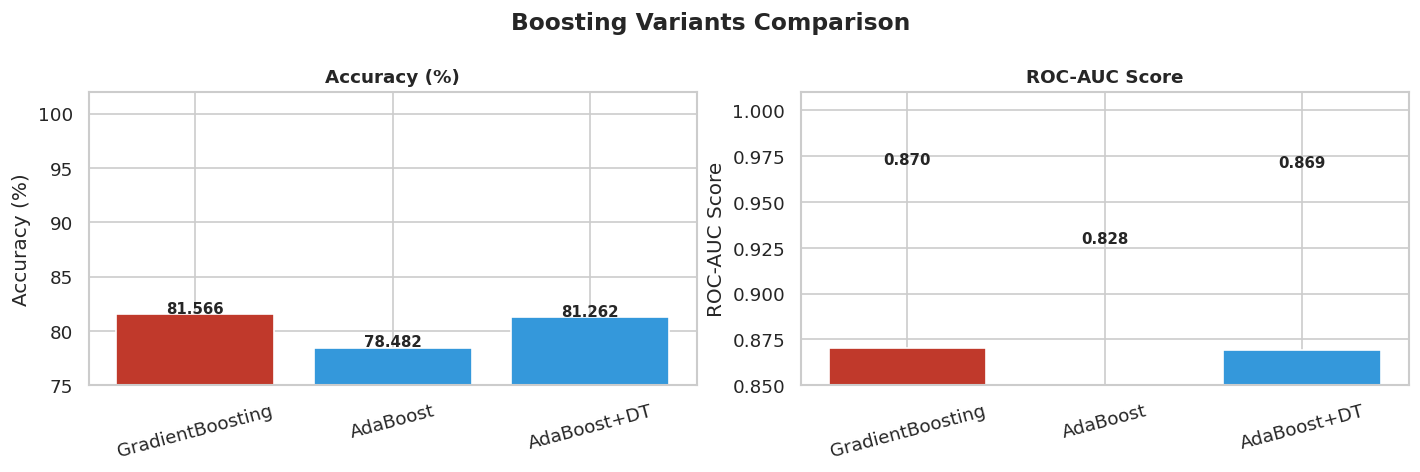

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

names    = list(baseline_results.keys())
bl_accs  = [baseline_results[n]['acc']*100
            for n in names]
bl_rocs  = [baseline_results[n]['roc']
            for n in names]
colors   = ['#c0392b' if n == best_baseline
            else '#3498db' for n in names]

for ax, vals, title, ylim in zip(
        axes,
        [bl_accs, bl_rocs],
        ['Accuracy (%)', 'ROC-AUC Score'],
        [(75, 102), (0.85, 1.01)]):
    bars = ax.bar(names, vals,
                  color=colors, edgecolor='white')
    ax.set_title(title, fontweight='bold',
                 fontsize=11)
    ax.set_ylabel(title)
    ax.set_ylim(ylim)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'{val:.3f}',
                ha='center', fontsize=9,
                fontweight='bold')

plt.suptitle('Boosting Variants Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('GB_09_baseline_comparison.png',
            bbox_inches='tight')
plt.show()

In [39]:
param_dist = {
    'n_estimators'      : [100, 200, 300],
    'learning_rate'     : [0.01, 0.05, 0.1],
    'max_depth'         : [2, 3, 4],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'subsample'         : [0.6, 0.7, 0.8],
    'max_features'      : ['sqrt', 'log2', 0.3, 0.5, None]
}

rand_search = RandomizedSearchCV(
    estimator   = GradientBoostingClassifier(
                      random_state=42),
    param_distributions = param_dist,
    n_iter      = 2,
    cv          = StratifiedKFold(2),
    scoring     = 'roc_auc',
    random_state= 42,
    n_jobs      = -1,
    verbose     = 1)

rand_search.fit(X_train, y_train)

print(f"\n✅ Best Params (Random): "
      f"{rand_search.best_params_}")
print(f"✅ Best CV ROC-AUC     : "
      f"{rand_search.best_score_:.4f}")

Fitting 2 folds for each of 2 candidates, totalling 4 fits

✅ Best Params (Random): {'subsample': 0.6, 'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 4, 'learning_rate': 0.1}
✅ Best CV ROC-AUC     : 0.8845


In [40]:
bp = rand_search.best_params_

param_grid = {
    'n_estimators': [bp['n_estimators']],
    'learning_rate': [
        bp['learning_rate'],
        bp['learning_rate'] + 0.02
    ],
    'max_depth': [
        bp['max_depth'],
        bp['max_depth'] + 1
    ],
    'subsample': [bp['subsample']],
    'max_features': [bp['max_features']],
    'min_samples_split': [bp['min_samples_split']],
    'min_samples_leaf': [bp['min_samples_leaf']]
}

grid_search = GridSearchCV(
    estimator  = GradientBoostingClassifier(
                     random_state=42),
    param_grid = param_grid,
    cv         = StratifiedKFold(2),
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1)

grid_search.fit(X_train, y_train)

print(f"\n✅ Best Params (Grid): "
      f"{grid_search.best_params_}")
print(f"✅ Best CV ROC-AUC   : "
      f"{grid_search.best_score_:.4f}")

Fitting 2 folds for each of 4 candidates, totalling 8 fits

✅ Best Params (Grid): {'learning_rate': 0.12000000000000001, 'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300, 'subsample': 0.6}
✅ Best CV ROC-AUC   : 0.8873


In [41]:
gb_best = grid_search.best_estimator_
gb_best.fit(X_train, y_train)

y_pred      = gb_best.predict(X_test)
y_pred_prob = gb_best.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_prob)
cv  = cross_val_score(
    gb_best, X_train, y_train,
    cv=StratifiedKFold(5),
    scoring='roc_auc')

bl_acc = baseline_results['GradientBoosting']['acc']
bl_roc = baseline_results['GradientBoosting']['roc']

print(f"\n{'Metric':<30} {'Baseline':>10} {'Tuned':>10}")
print("-" * 52)
print(f"{'Accuracy':<30} "
      f"{bl_acc*100:>9.2f}% {acc*100:>9.2f}%")
print(f"{'ROC-AUC':<30} "
      f"{bl_roc:>10.4f} {roc:>10.4f}")
print(f"{'CV ROC-AUC (mean)':<30} "
      f"{'—':>10} {cv.mean():>10.4f}")
print(f"{'CV ROC-AUC (std)':<30} "
      f"{'—':>10} {cv.std():>10.4f}")
print(f"{'n_estimators':<30} "
      f"{'100':>10} "
      f"{gb_best.n_estimators_:>10}")

print(f"\n Classification Report:\n")
print(classification_report(
    y_test, y_pred,
    target_names=['Not Canceled', 'Canceled']))


Metric                           Baseline      Tuned
----------------------------------------------------
Accuracy                           81.57%     83.92%
ROC-AUC                            0.8703     0.8994
CV ROC-AUC (mean)                       —     0.8924
CV ROC-AUC (std)                        —     0.0008
n_estimators                          100        300

 Classification Report:

              precision    recall  f1-score   support

Not Canceled       0.87      0.91      0.89     12644
    Canceled       0.73      0.65      0.69      4802

    accuracy                           0.84     17446
   macro avg       0.80      0.78      0.79     17446
weighted avg       0.83      0.84      0.84     17446



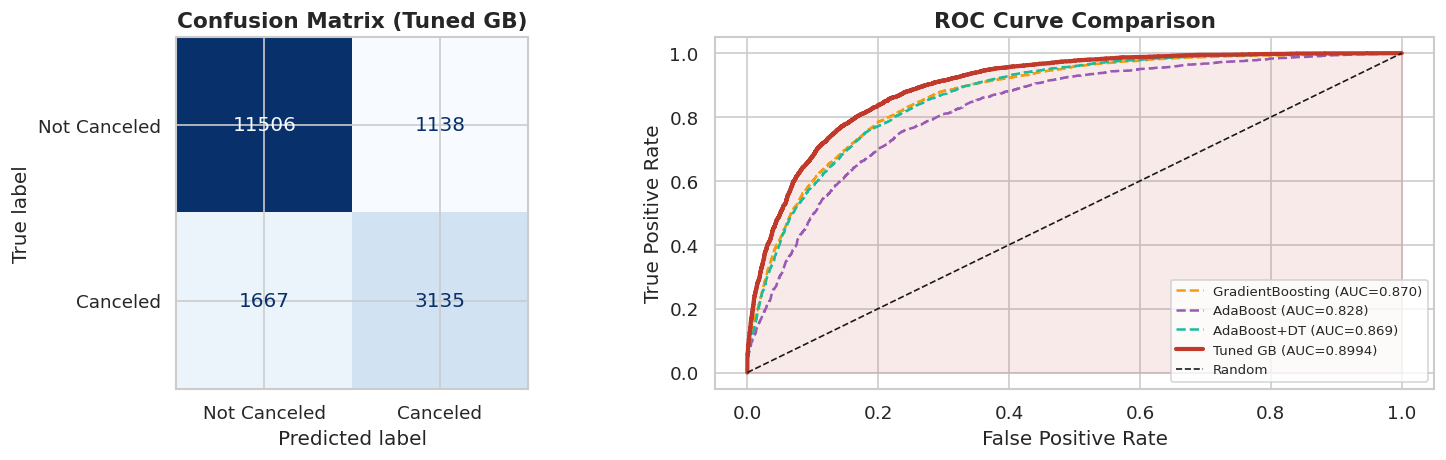

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Canceled', 'Canceled'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Tuned GB)',
                  fontsize=13, fontweight='bold')

# ROC — all variants
colors_roc = ['#f39c12', '#9b59b6',
               '#1abc9c', '#c0392b']
for (name, res), color in zip(
        baseline_results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(
        y_test,
        res['model'].predict_proba(X_test)[:, 1])
    axes[1].plot(fpr, tpr, lw=1.5,
                 linestyle='--', color=color,
                 label=f'{name} '
                       f'(AUC={res["roc"]:.3f})')

fpr_t, tpr_t, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr_t, tpr_t, color='#c0392b',
             lw=2.5,
             label=f'Tuned GB '
                   f'(AUC={roc:.4f})')
axes[1].fill_between(fpr_t, tpr_t,
                     alpha=0.1, color='#c0392b')
axes[1].plot([0,1],[0,1], 'k--', lw=1,
             label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison',
                  fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('GB_10_confusion_roc.png',
            bbox_inches='tight')
plt.show()

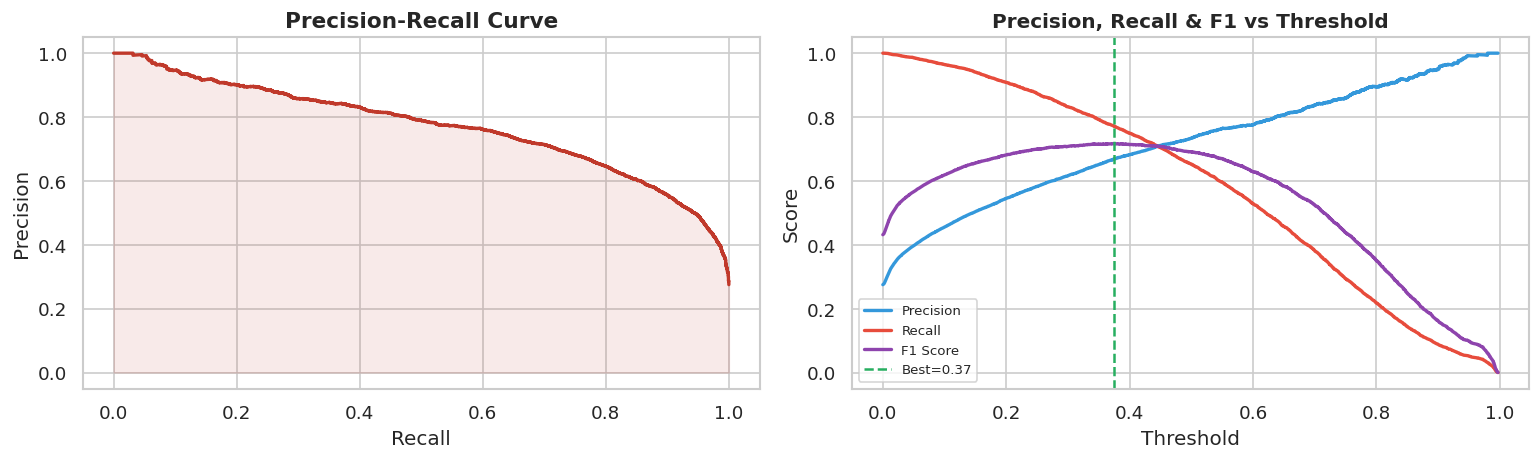

In [43]:
precision, recall, thresholds = precision_recall_curve(
    y_test, y_pred_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(recall, precision,
             color='#c0392b', lw=2)
axes[0].fill_between(recall, precision,
                     alpha=0.1, color='#c0392b')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve',
                  fontsize=13, fontweight='bold')

f1_scores   = (2 * precision[:-1] * recall[:-1] /
               (precision[:-1] + recall[:-1] + 1e-8))
best_thresh = thresholds[np.argmax(f1_scores)]

axes[1].plot(thresholds, precision[:-1],
             color='#3498db', lw=2,
             label='Precision')
axes[1].plot(thresholds, recall[:-1],
             color='#e74c3c', lw=2,
             label='Recall')
axes[1].plot(thresholds, f1_scores,
             color='#8e44ad', lw=2,
             label='F1 Score')
axes[1].axvline(x=best_thresh,
                color='#27ae60',
                linestyle='--',
                label=f'Best={best_thresh:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision, Recall & F1 vs Threshold',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('GB_11_precision_recall.png',
            bbox_inches='tight')
plt.show()

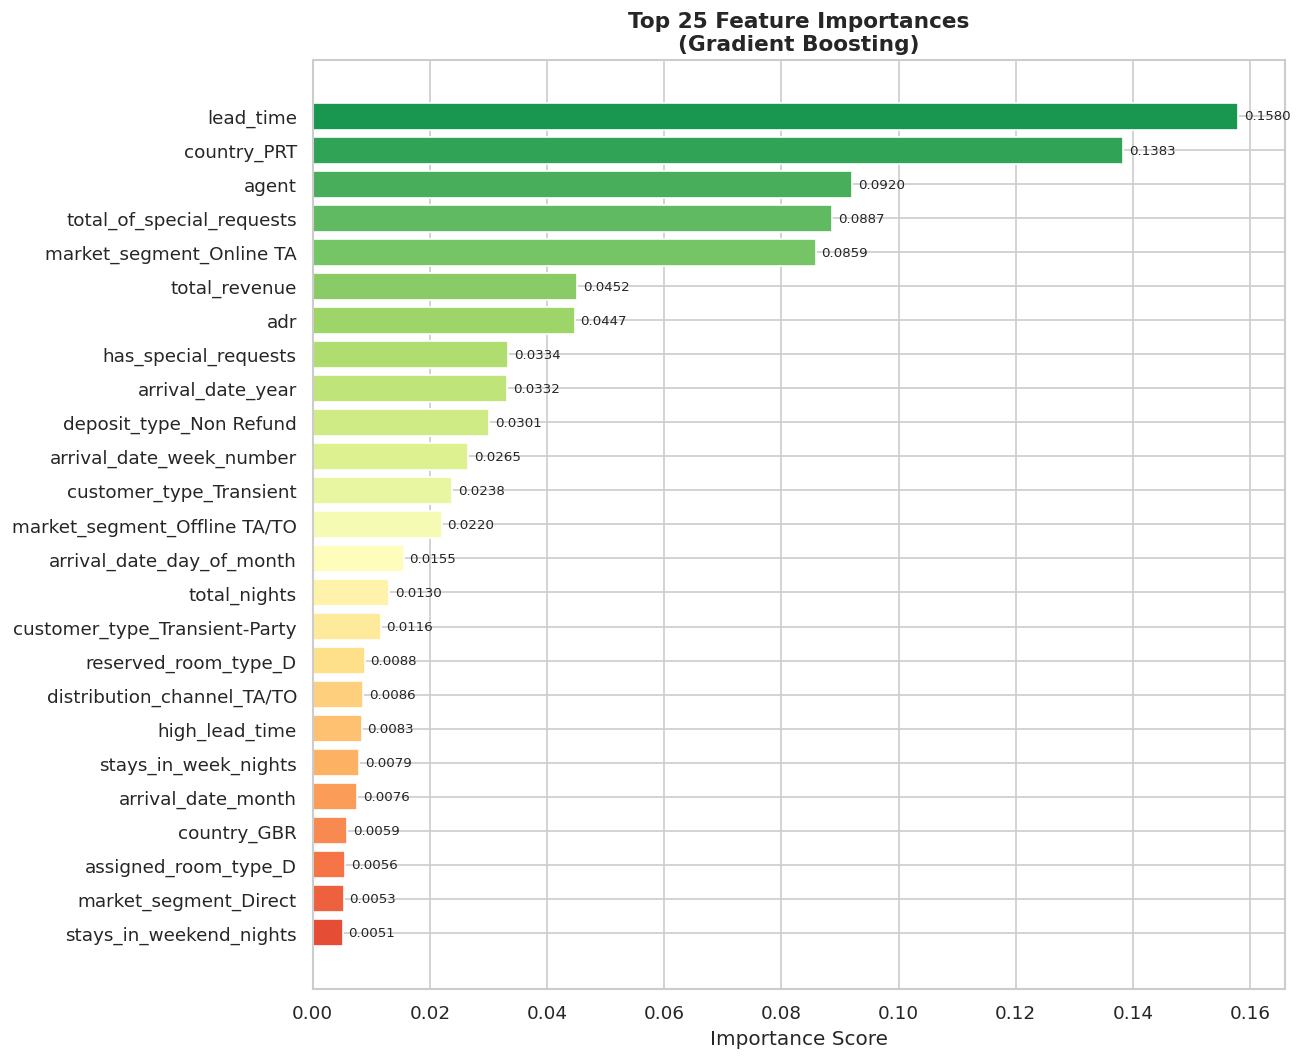

In [44]:
feature_names = X.columns.tolist()
importances   = gb_best.feature_importances_

feat_imp = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances
}).sort_values('Importance',
               ascending=False).head(25)

fig, ax = plt.subplots(figsize=(11, 9))
colors  = plt.cm.RdYlGn(
    np.linspace(0.15, 0.9, len(feat_imp)))[::-1]

bars = ax.barh(feat_imp['Feature'],
               feat_imp['Importance'],
               color=colors, edgecolor='white')
ax.set_title('Top 25 Feature Importances\n'
             '(Gradient Boosting)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()

for bar, val in zip(bars, feat_imp['Importance']):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}',
            va='center', fontsize=8)

plt.tight_layout()
plt.savefig('GB_12_feature_importance.png',
            bbox_inches='tight')
plt.show()

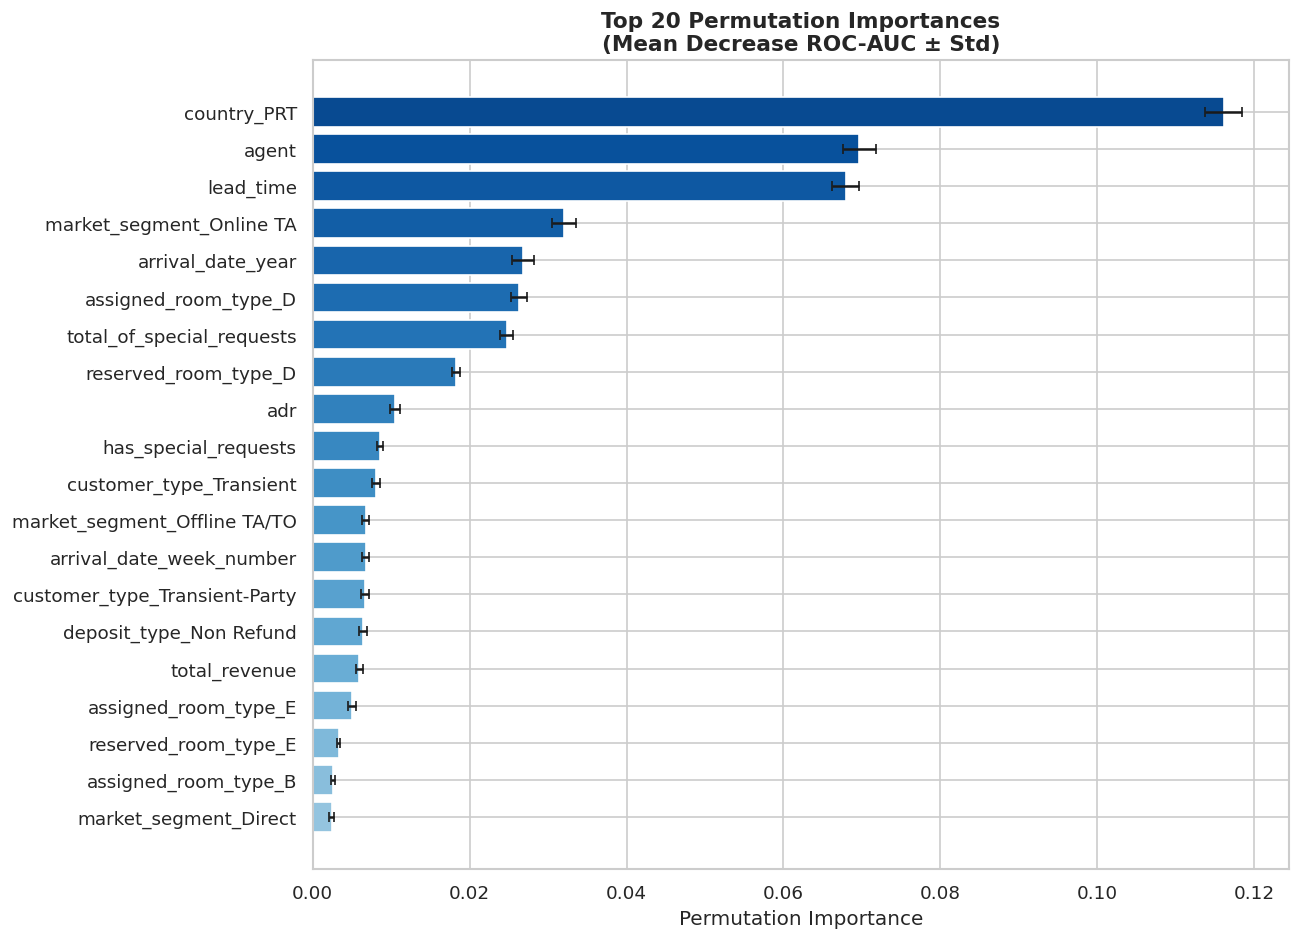

In [45]:
perm_imp = permutation_importance(
    gb_best, X_test, y_test,
    n_repeats    = 10,
    random_state = 42,
    scoring      = 'roc_auc',
    n_jobs       = -1)

perm_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': perm_imp.importances_mean,
    'Std'       : perm_imp.importances_std
}).sort_values('Importance',
               ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 8))
colors  = plt.cm.Blues(
    np.linspace(0.4, 0.9, len(perm_df)))[::-1]

ax.barh(perm_df['Feature'],
        perm_df['Importance'],
        xerr=perm_df['Std'],
        color=colors,
        edgecolor='white',
        capsize=3)
ax.set_title('Top 20 Permutation Importances\n'
             '(Mean Decrease ROC-AUC ± Std)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Permutation Importance')
ax.axvline(x=0, color='red',
           linestyle='--', linewidth=1)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('GB_13_permutation_importance.png',
            bbox_inches='tight')
plt.show()

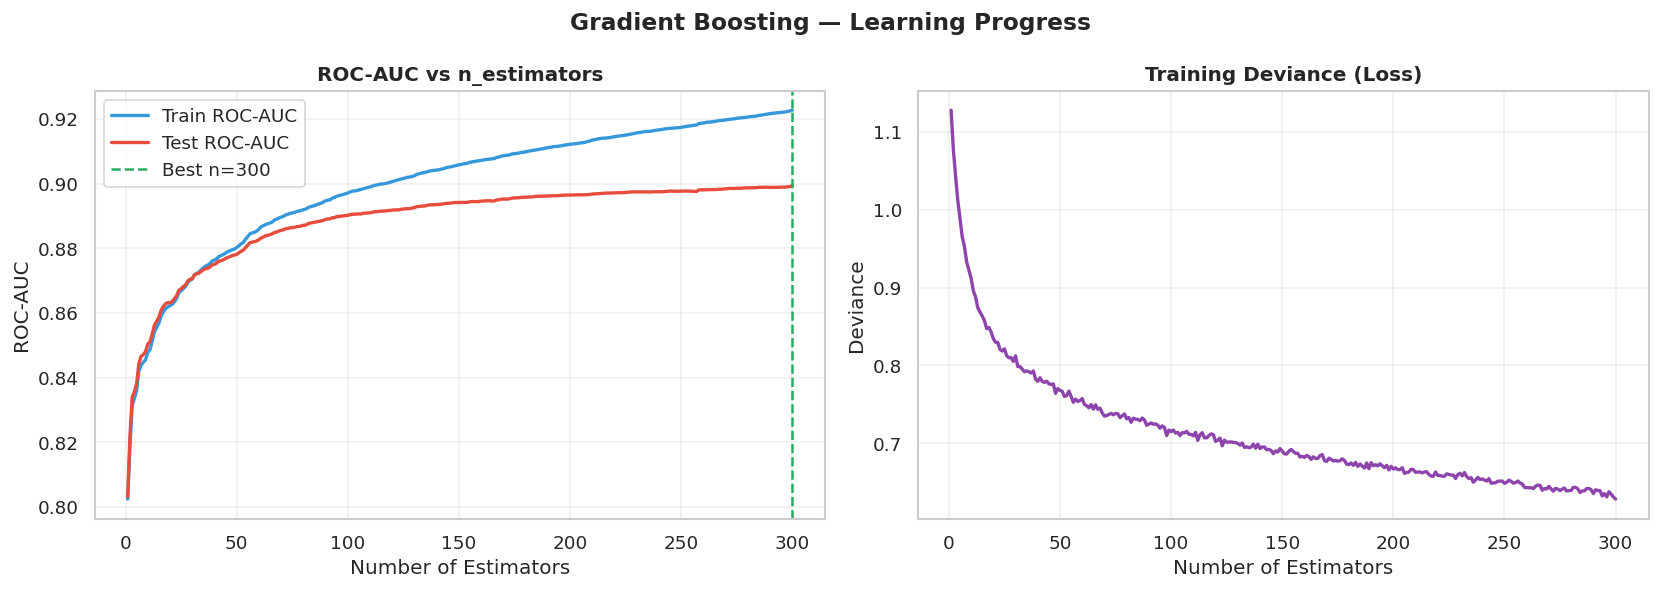

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training deviance
train_score = np.zeros(
    gb_best.n_estimators_, dtype=np.float64)
test_score  = np.zeros(
    gb_best.n_estimators_, dtype=np.float64)

for i, y_pred_stage in enumerate(
        gb_best.staged_predict_proba(X_test)):
    test_score[i] = roc_auc_score(
        y_test, y_pred_stage[:, 1])

for i, y_pred_stage in enumerate(
        gb_best.staged_predict_proba(X_train)):
    train_score[i] = roc_auc_score(
        y_train, y_pred_stage[:, 1])

n_trees = np.arange(gb_best.n_estimators_) + 1

axes[0].plot(n_trees, train_score,
             color='#3498db', lw=2,
             label='Train ROC-AUC')
axes[0].plot(n_trees, test_score,
             color='#e74c3c', lw=2,
             label='Test ROC-AUC')
axes[0].axvline(
    x=n_trees[np.argmax(test_score)],
    color='#27ae60', linestyle='--',
    label=f'Best n='
          f'{n_trees[np.argmax(test_score)]}')
axes[0].set_title('ROC-AUC vs n_estimators',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Estimators')
axes[0].set_ylabel('ROC-AUC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Train loss
train_deviance = gb_best.train_score_
axes[1].plot(n_trees, train_deviance,
             color='#8e44ad', lw=2)
axes[1].set_title('Training Deviance (Loss)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Estimators')
axes[1].set_ylabel('Deviance')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Gradient Boosting — '
             'Learning Progress',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('GB_14_learning_progress.png',
            bbox_inches='tight')
plt.show()

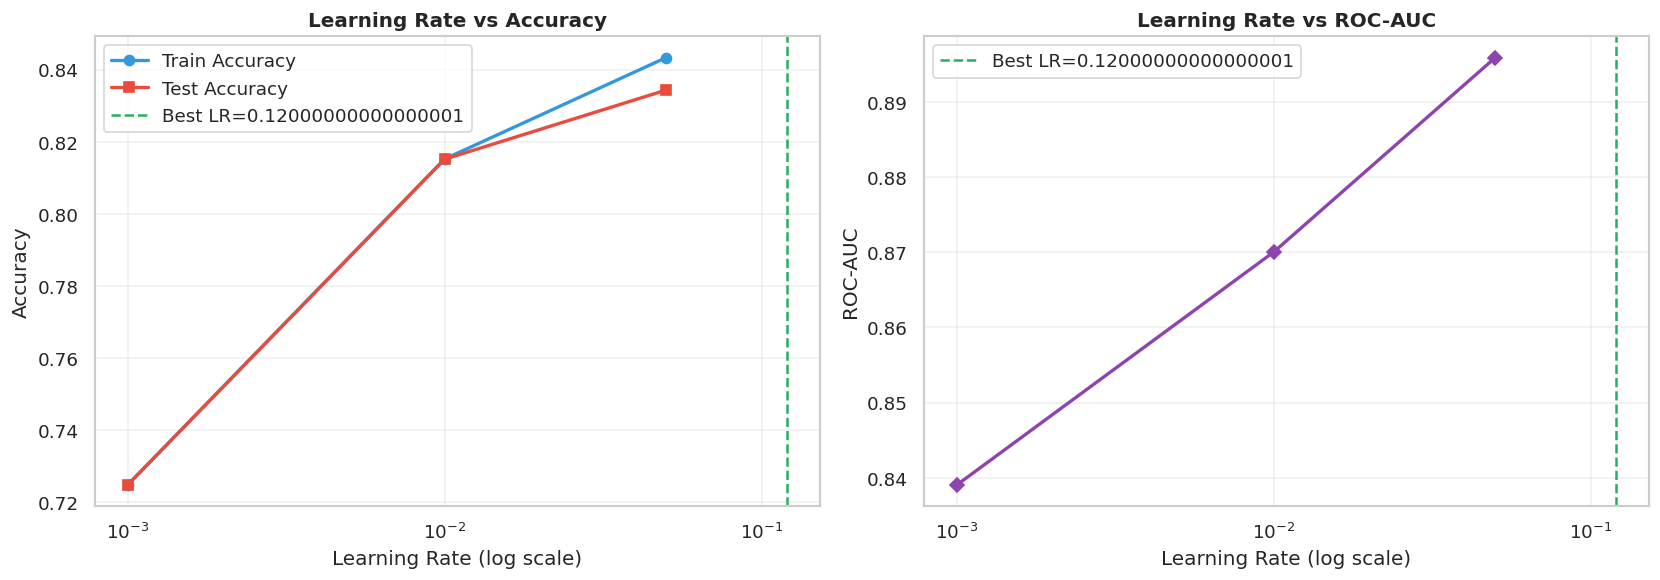

In [49]:
lr_values  = [0.001, 0.01, 0.05]
lr_train   = []
lr_test    = []
lr_roc     = []

for lr in lr_values:
    gb_lr = GradientBoostingClassifier(
        n_estimators  = gb_best.n_estimators_,
        learning_rate = lr,
        max_depth     = gb_best.max_depth,
        subsample     = gb_best.subsample,
        random_state  = 42)
    gb_lr.fit(X_train, y_train)
    lr_train.append(
        accuracy_score(y_train,
                       gb_lr.predict(X_train)))
    lr_test.append(
        accuracy_score(y_test,
                       gb_lr.predict(X_test)))
    lr_roc.append(
        roc_auc_score(
            y_test,
            gb_lr.predict_proba(X_test)[:, 1]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(lr_values, lr_train, 'o-',
                 color='#3498db', lw=2,
                 label='Train Accuracy')
axes[0].semilogx(lr_values, lr_test, 's-',
                 color='#e74c3c', lw=2,
                 label='Test Accuracy')
axes[0].axvline(
    x=gb_best.learning_rate,
    color='#27ae60', linestyle='--',
    label=f'Best LR={gb_best.learning_rate}')
axes[0].set_title('Learning Rate vs Accuracy',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Learning Rate (log scale)')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(lr_values, lr_roc, 'D-',
                 color='#8e44ad', lw=2)
axes[1].axvline(
    x=gb_best.learning_rate,
    color='#27ae60', linestyle='--',
    label=f'Best LR={gb_best.learning_rate}')
axes[1].set_title('Learning Rate vs ROC-AUC',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Learning Rate (log scale)')
axes[1].set_ylabel('ROC-AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('GB_15_learning_rate.png',
            bbox_inches='tight')
plt.show()

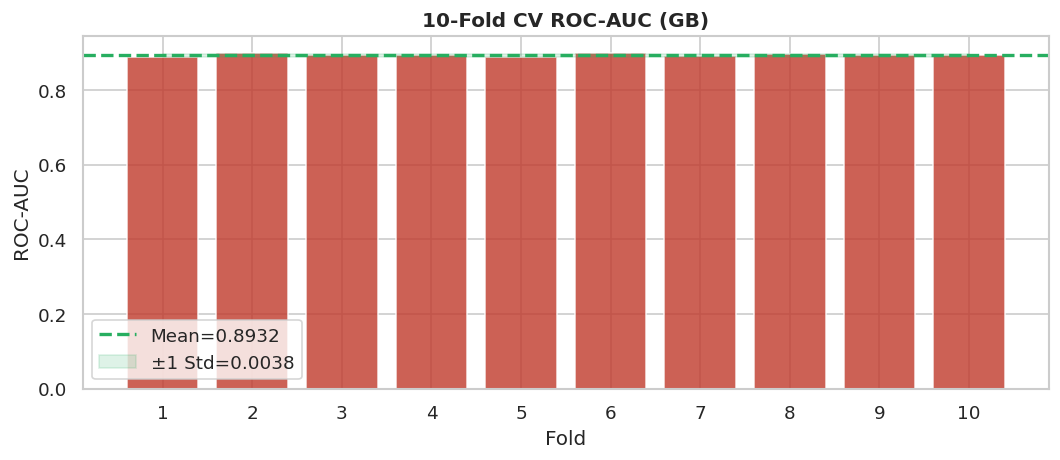

In [50]:
cv_scores_10 = cross_val_score(gb_best, X_train, y_train,cv=StratifiedKFold(10),scoring='roc_auc')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, 11), cv_scores_10,color='#c0392b', edgecolor='white',alpha=0.8)
ax.axhline(y=cv_scores_10.mean(),color='#27ae60', linestyle='--',lw=2,label=f'Mean={cv_scores_10.mean():.4f}')

ax.fill_between(
    range(1, 11),
    cv_scores_10.mean() - cv_scores_10.std(),
    cv_scores_10.mean() + cv_scores_10.std(),
    alpha=0.15, color='#27ae60',
    label=f'±1 Std={cv_scores_10.std():.4f}')
ax.set_title('10-Fold CV ROC-AUC (GB)',fontsize=12, fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('ROC-AUC')
ax.set_xticks(range(1, 11))
ax.legend()
plt.tight_layout()
plt.savefig('GB_16_cv_scores.png',bbox_inches='tight')
plt.show()

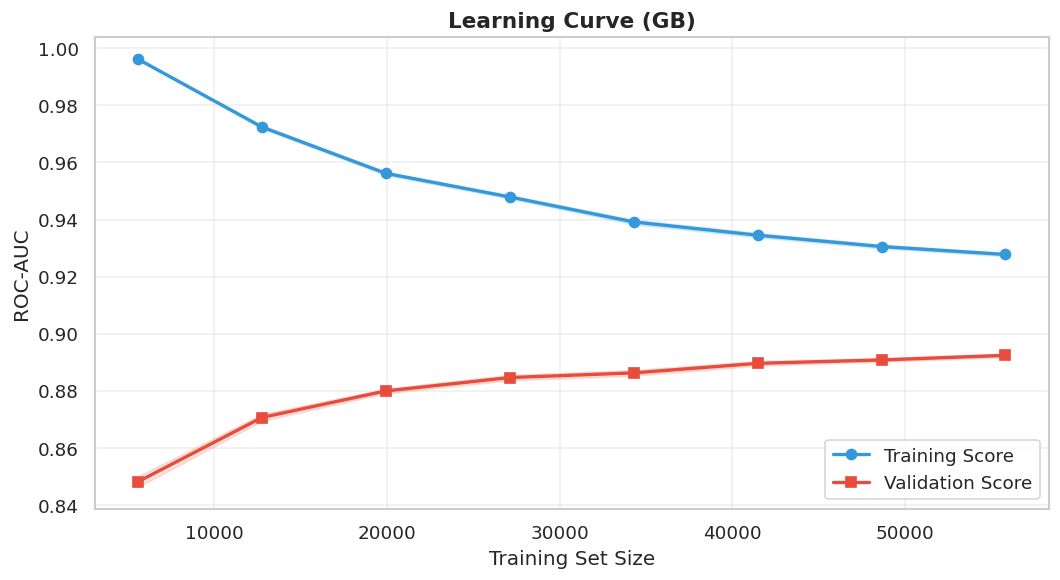

In [52]:
train_sizes, train_sc, val_sc = learning_curve(
    gb_best, X_train, y_train,
    train_sizes = np.linspace(0.1, 1.0, 8),
    cv          = StratifiedKFold(5),
    scoring     = 'roc_auc',
    n_jobs      = -1)

train_mean = train_sc.mean(axis=1)
train_std  = train_sc.std(axis=1)
val_mean   = val_sc.mean(axis=1)
val_std    = val_sc.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-',
        color='#3498db', lw=2,
        label='Training Score')
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color='#3498db')
ax.plot(train_sizes, val_mean, 's-',
        color='#e74c3c', lw=2,
        label='Validation Score')
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color='#e74c3c')
ax.set_title('Learning Curve (GB)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('ROC-AUC')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('GB_17_learning_curve.png',
            bbox_inches='tight')
plt.show()

In [53]:
# Save best GB model
joblib.dump(gb_best,
            'gb_hotel_model.pkl')
print("✅ GB Model saved      → gb_hotel_model.pkl")

# Save scaler
joblib.dump(scaler, 'GB_scaler.pkl')
print("✅ Scaler saved        → GB_scaler.pkl")

# Save feature names
pd.DataFrame({
    'features': feature_names
}).to_csv('GB_feature_names.csv', index=False)
print("✅ Features saved      → GB_feature_names.csv")

# Save feature importances
feat_imp_full = pd.DataFrame({
    'Feature'          : feature_names,
    'GB_Importance'    : importances,
    'Permutation_Imp'  : perm_imp.importances_mean
}).sort_values('GB_Importance', ascending=False)
feat_imp_full.to_csv(
    'GB_feature_importances.csv', index=False)
print("✅ Importances saved   → "
      "GB_feature_importances.csv")

# Save GridSearch results
pd.DataFrame(
    grid_search.cv_results_
).to_csv('GB_gridsearch_results.csv', index=False)
print("✅ GridSearch saved    → "
      "GB_gridsearch_results.csv")

# Save staged scores
pd.DataFrame({
    'n_estimators' : n_trees,
    'train_roc'    : train_score,
    'test_roc'     : test_score
}).to_csv('GB_staged_scores.csv', index=False)
print("✅ Staged scores saved → GB_staged_scores.csv")

# ── Download in Google Colab ──────────────────────────────────
try:
    from google.colab import files
    files.download('gb_hotel_model.pkl')
    files.download('GB_scaler.pkl')
    files.download('GB_feature_names.csv')
    files.download('GB_feature_importances.csv')
    files.download('GB_gridsearch_results.csv')
    files.download('GB_staged_scores.csv')
    print("\n🎉 All files downloaded to your PC!")
except ImportError:
    print("\n📁 Not in Colab — saved locally:")
    print(f"   → {os.path.abspath('gb_hotel_model.pkl')}")
    print(f"   → {os.path.abspath('GB_feature_names.csv')}")

✅ GB Model saved      → gb_hotel_model.pkl
✅ Scaler saved        → GB_scaler.pkl
✅ Features saved      → GB_feature_names.csv
✅ Importances saved   → GB_feature_importances.csv
✅ GridSearch saved    → GB_gridsearch_results.csv
✅ Staged scores saved → GB_staged_scores.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 All files downloaded to your PC!


In [54]:
loaded_model = joblib.load('gb_hotel_model.pkl')

sample      = X_test.iloc[:6]
predictions = loaded_model.predict(sample)
proba       = loaded_model.predict_proba(sample)[:, 1]
actuals     = y_test.values[:6]

print("\n📊 Sample Predictions:")
print(f"{'#':<4} {'Prediction':<20} "
      f"{'P(Cancel)':>10} {'Actual':>15}")
print("-" * 55)

for i, (pred, prob, actual) in enumerate(
        zip(predictions, proba, actuals)):
    label    = ("🔴 CANCELED"
                if pred   == 1
                else "🟢 NOT CANCELED")
    act_lbl  = ("CANCELED"
                if actual == 1
                else "NOT CANCELED")
    correct  = "✅" if pred == actual else "❌"
    print(f"{i+1:<4} {label:<20} "
          f"{prob*100:>9.2f}% "
          f"{act_lbl:>14} {correct}")


📊 Sample Predictions:
#    Prediction            P(Cancel)          Actual
-------------------------------------------------------
1    🟢 NOT CANCELED           16.65%   NOT CANCELED ✅
2    🔴 CANCELED               59.26%       CANCELED ✅
3    🟢 NOT CANCELED            3.89%   NOT CANCELED ✅
4    🟢 NOT CANCELED            5.93%   NOT CANCELED ✅
5    🟢 NOT CANCELED            0.48%   NOT CANCELED ✅
6    🟢 NOT CANCELED           13.44%   NOT CANCELED ✅


In [55]:
print(f"  Dataset             : Hotel Booking Demand")
print(f"  Dataset Shape       : {df.shape}")
print(f"  Features Used       : {X.shape[1]}")
print(f"  Training Samples    : {X_train.shape[0]:,}")
print(f"  Test Samples        : {X_test.shape[0]:,}")
print(f"  Best Parameters     : "
      f"{grid_search.best_params_}")
print(f"  Baseline Accuracy   : {bl_acc*100:.2f}%")
print(f"  Tuned Accuracy      : {acc*100:.2f}%")
print(f"  Baseline ROC-AUC    : {bl_roc:.4f}")
print(f"  Tuned ROC-AUC       : {roc:.4f}")
print(f"  CV ROC-AUC          : "
      f"{cv.mean():.4f} ± {cv.std():.4f}")
print(f"  Best F1 Threshold   : {best_thresh:.4f}")
print(f"  n_estimators        : {gb_best.n_estimators_}")
print(f"  Learning Rate       : {gb_best.learning_rate}")
print(f"  Max Depth           : {gb_best.max_depth}")

print(" Saved Files:")
print("   gb_hotel_model.pkl")
print("   GB_scaler.pkl")
print("   GB_feature_names.csv")
print("   GB_feature_importances.csv")
print("   GB_gridsearch_results.csv")
print("   GB_staged_scores.csv")
print("    GB_01 ~ GB_17 PNG files")


  Dataset             : Hotel Booking Demand
  Dataset Shape       : (87229, 30)
  Features Used       : 86
  Training Samples    : 69,783
  Test Samples        : 17,446
  Best Parameters     : {'learning_rate': 0.12000000000000001, 'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300, 'subsample': 0.6}
  Baseline Accuracy   : 81.57%
  Tuned Accuracy      : 83.92%
  Baseline ROC-AUC    : 0.8703
  Tuned ROC-AUC       : 0.8994
  CV ROC-AUC          : 0.8924 ± 0.0008
  Best F1 Threshold   : 0.3748
  n_estimators        : 300
  Learning Rate       : 0.12000000000000001
  Max Depth           : 5
 Saved Files:
   gb_hotel_model.pkl
   GB_scaler.pkl
   GB_feature_names.csv
   GB_feature_importances.csv
   GB_gridsearch_results.csv
   GB_staged_scores.csv
    GB_01 ~ GB_17 PNG files
